<a href="https://colab.research.google.com/github/alain-odag-rty/Inteligencia-Artificial-Prueba/blob/main/asignacion_2_regresion_Alain_Oda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Descripción del data set Financial data of 4400+ public companies

✅ ¿Qué es?

Se trata de un conjunto de datos que contiene información financiera de más de 4 400 empresas públicas.  

Los datos fueron raspados (“scraped”) de Yahoo Finance, lo que incluye los estados financieros — el balance general (“balance sheet”), el estado de resultados (“income statement”), y el flujo de caja (“cash flow statement”).  

Incluye datos tanto anuales como trimestrales para un período reciente (aproximadamente los últimos 4 años) para cada empresa.  


# ¿Qué contiene exactamente?

Algunas de las características clave de la base de datos:

- Cada empresa viene identificada con su ticker o símbolo bursátil (o equivalente) y posiblemente con su nombre, industria, etc.
- Para cada empresa, los datos incluyen:
    - Estado de resultados: ingresos, beneficios, gastos, etc.
    - Balance general: activos, pasivos, capital contable, etc.
    - Flujo de caja: flujos operativos, de inversión, de financiación, etc.
- Los datos están organizados para que puedas ver la evolución por trimestre y por año, lo que permite análisis de tendencias.
- Se pueden usar variables financieras como predictors (por ejemplo: activos, pasivos, ingresos) y variables objetivo como beneficio, rentabilidad, crecimiento, etc.

# Paso 1 — Reconocer el dataset

1. Objetivo: investigar el dataset entregado en la asignación 2, revisar el nombre de cada columna y documentar qué representa cada una (tipo, unidad, periodicidad, observaciones).

2. Pasos recomendados:
    - Cargar el archivo entregado (por ejemplo: df = pd.read_csv(...)) y listar columnas: df.columns
    - Para cada columna: buscar su significado (glosario, documentación de la fuente, o inspección de valores).
    - Anotar tipo de dato, unidad (USD, porcentaje, entero), periodicidad (trimestral/anual) y cualquier observación (por ejemplo: calculada, acumulada, neta/bruta).
    - Generar la lista final con nombre y descripción clara y breve.

3. Ejemplo de Plantilla para la lista (reemplazar con las columnas reales del dataset):

- ticker: Identificador bursátil de la empresa (string). Ejemplo: "AAPL".
- fiscal_date: Fecha del periodo financiero (YYYY-MM-DD). Indica el cierre del trimestre/año.
- revenue: Ingresos netos durante el periodo (num, USD). Periodicidad: trimestral/anual.
- gross_profit: Beneficio bruto (num, USD). Definición: ingresos menos costo de ventas.
- operating_income: Resultado operativo (num, USD). Incluye gastos operativos.
- net_income: Beneficio neto después de impuestos (num, USD).


4. Resultado esperado:
    - Un listado documentado con cada columna del dataset y su descripción (puede entregarse como tabla o como lista de pares nombre→descripción).

In [35]:
import pandas as pd

# Cargar dataset
df = pd.read_csv("/content/balanceSheetHistory_annually.csv")

# Ver primeras filas
print(df.head())

# Ver columnas
print(df.columns)

# Ver tipos de datos
print(df.info())

  stock     endDate  accountsPayable    inventory  longTermDebt  \
0   IVC  2019-12-31       88003000.0  121184000.0   219464000.0   
1   IVC  2018-12-31       92469000.0  128644000.0   225733000.0   
2   IVC  2017-12-31       90566000.0  121933000.0   241405000.0   
3   IVC  2016-12-31       88236000.0  135644000.0   146088000.0   
4  CSLT  2019-12-31       19596000.0          NaN           NaN   

   netReceivables  netTangibleAssets  longTermInvestments  totalCurrentAssets  \
0     140013000.0        -91334000.0              85000.0         355877000.0   
1     138476000.0        -48632000.0              90000.0         397410000.0   
2     143464000.0         -8233000.0             103000.0         456914000.0   
3     132707000.0         32762000.0             108000.0         409072000.0   
4      31397000.0         68911000.0                  NaN          95470000.0   

   propertyPlantEquipment  ...   totalAssets  otherCurrentLiab  \
0              92183000.0  ...  8.521260e+08

# Paso 2 — Seleccionar columnas relevantes

Después de haber cargado el dataset, elimina todas las columnas y quédate solo con: `stock`, `endDate` y `cash`.

- Verifica que los nombres y la capitalización de las columnas sean correctos antes de seleccionar.


In [36]:
# Verificar nombres exactos
print(df.columns)

# Seleccionar columnas necesarias
df = df[['stock','endDate','cash']]

# Verificar
print(df.head())

Index(['stock', 'endDate', 'accountsPayable', 'inventory', 'longTermDebt',
       'netReceivables', 'netTangibleAssets', 'longTermInvestments',
       'totalCurrentAssets', 'propertyPlantEquipment',
       'otherStockholderEquity', 'deferredLongTermAssetCharges',
       'totalCurrentLiabilities', 'cash', 'otherAssets', 'treasuryStock',
       'goodWill', 'otherLiab', 'retainedEarnings', 'otherCurrentAssets',
       'commonStock', 'totalAssets', 'otherCurrentLiab',
       'deferredLongTermLiab', 'totalStockholderEquity', 'totalLiab',
       'capitalSurplus', 'intangibleAssets', 'shortTermInvestments',
       'shortLongTermDebt', 'minorityInterest'],
      dtype='object')
  stock     endDate         cash
0   IVC  2019-12-31   80063000.0
1   IVC  2018-12-31  116907000.0
2   IVC  2017-12-31  176528000.0
3   IVC  2016-12-31  124234000.0
4  CSLT  2019-12-31   43017000.0


# Paso 3 — Separar por empresas y elegir 3 para predecir su cantidad de dinero por fecha

- Objetivo: crear series temporales por empresa usando las columnas `stock`, `endDate` y `cash` y seleccionar 3 empresas para modelar y predecir `cash` por fecha.
- Pasos recomendados:
    - Verificar que las columnas `stock`, `endDate` y `cash` existen y están limpias (sin valores nulos o con imputación cuando sea necesario).
    - Ordenar el dataframe por `stock` y `endDate` (ascendente) para obtener la serie temporal de cada empresa.
    - Agrupar por `stock` y crear un subset por empresa.
    - Elegir 3 empresas con suficientes observaciones (p. ej. mayor número de fechas disponibles o relevancia del negocio).
    - Para cada empresa seleccionada, preparar los datos de entrenamiento/validación (features temporales, ventanas, lag, etc.) y definir la variable objetivo `cash` por `endDate`.

In [37]:
# Limpiar datos
df = df.dropna()

# Convertir fecha
df['endDate'] = pd.to_datetime(df['endDate'])

# Ordenar
df = df.sort_values(['stock','endDate'])

# Agrupar por empresa
grouped = df.groupby('stock')

# Ver empresas con más datos
counts = df['stock'].value_counts()

# elegir empresas con suficientes datos
counts = counts[counts >= 4]

stocks = counts.head(3).index.tolist()

print(stocks)
# Crear subconjuntos
company1 = df[df['stock']==stocks[0]]
company2 = df[df['stock']==stocks[1]]
company3 = df[df['stock']==stocks[2]]

['ZYXI', 'A', 'ZIXI']


# Paso 4 — Grafique tiempo vs dinero de las 3 empresas en 3 gráficas diferentes

Objetivo: visualizar la serie temporal de `cash` frente a `endDate` para cada una de las 3 empresas seleccionadas, colocando cada empresa en una gráfica independiente.

Pasos recomendados:
- Asegurarse de tener el DataFrame con las columnas `stock`, `endDate` y `cash` y ordenado por `stock` y `endDate` ascendente.
- Convertir `endDate` a tipo fecha: `df['endDate'] = pd.to_datetime(df['endDate'])`.
- Seleccionar las 3 empresas elegidas: p. ej. `stocks = ['AAA','BBB','CCC']` y crear un subset por cada `stock`.
- Para cada empresa, graficar `endDate` en el eje x y `cash` en el eje y en una figura separada.
- Configurar títulos, etiquetas de ejes y formato de fechas (rotar etiquetas si es necesario). Añadir grid y leyenda si procede.
- Opcional: usar subplots (3 filas x 1 columna) para mostrar las 3 gráficas en la misma figura o generar 3 figuras individuales según preferencia.
- Guardar las figuras si es necesario: `plt.savefig('cash_stock_AAA.png', bbox_inches='tight')`.

Ejemplo de librerías a usar: matplotlib, seaborn o plotly para interactividad.

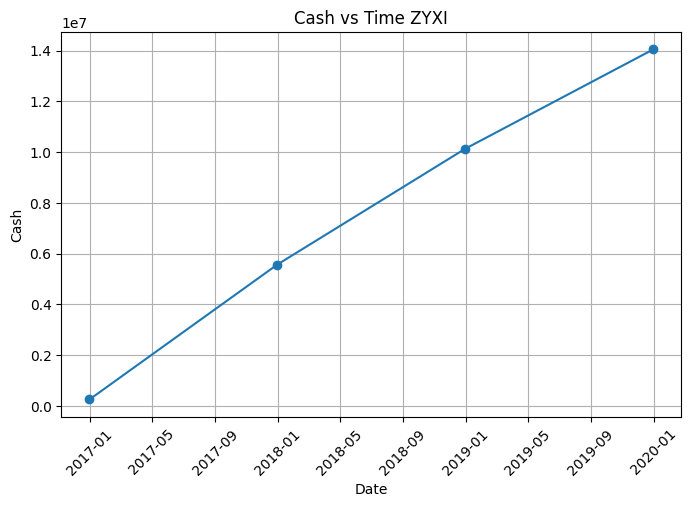

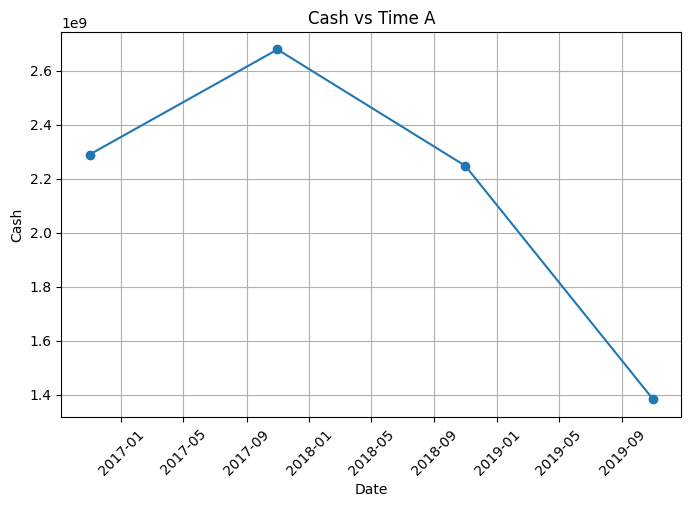

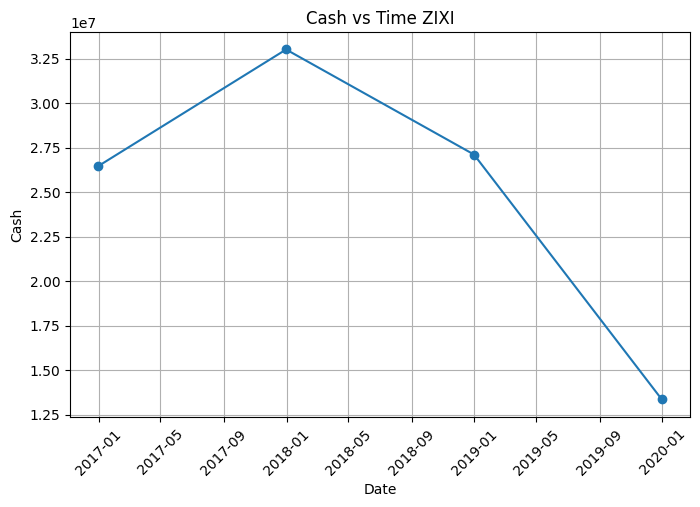

In [38]:
import matplotlib.pyplot as plt

companies = [company1,company2,company3]

for company in companies:

    plt.figure(figsize=(8,5))

    plt.plot(company['endDate'],
             company['cash'],
             marker='o')

    plt.title("Cash vs Time "+company['stock'].iloc[0])

    plt.xlabel("Date")

    plt.ylabel("Cash")

    plt.grid()

    plt.xticks(rotation=45)

    plt.show()

# Paso 5 — División 80/20 (entrenamiento / prueba)

Objetivo: separar los datos en 80% para entrenamiento y 20% para prueba respetando la estructura temporal por empresa (sin hacer shuffle).

Recomendaciones:
- Asegúrate de tener las columnas `stock`, `endDate` y `cash` y que el dataframe esté ordenado por `stock` y `endDate` (ascendente).
- Para series temporales por empresa, usa una división basada en tiempo: los primeros 80% de observaciones de cada `stock` → train; los últimos 20% → test.



In [39]:
train_sets = {}
test_sets = {}

for stock in stocks:

    company = df[df['stock']==stock]

    split = int(len(company)*0.8)

    train = company.iloc[:split]

    test = company.iloc[split:]

    train_sets[stock]=train

    test_sets[stock]=test

# Paso 6 — crea y entrena el modelo de regresión lineal para predecir `cash` por empresa

Objetivo: entrenar un modelo de regresión lineal por cada `stock` usando la serie temporal (respetando orden temporal) y evaluar en el 20% final.

Pasos recomendados:
- Preprocesamiento
    - Definir variables para el entrenamiento: y = `cash` (variable objetivo). `data` → X (conjunto de características a usar para predecir `cash`, p. ej. rezagos de `cash`, indicadores temporales, variables exógenas). Usar X e y en el entrenamiento: `model.fit(X_train, y_train)`.
    - Asegurar `endDate` como datetime y ordenar por `stock`, `endDate`.  - Asegurar `endDate` como datetime y ordenar por `stock`, `endDate`.



In [40]:
from sklearn.linear_model import LinearRegression

models={}
predictions={}

for stock in stocks:

    company=df[df['stock']==stock].copy()

    # Crear lag antes del split
    company['lag1']=company['cash'].shift(1)

    company=company.dropna()

    # Split temporal
    split=int(len(company)*0.8)

    train=company.iloc[:split]

    test=company.iloc[split:]

    # Features
    X_train=train[['lag1']]
    y_train=train['cash']

    X_test=test[['lag1']]
    y_test=test['cash']

    # Modelo
    model=LinearRegression()

    model.fit(X_train,y_train)

    y_pred=model.predict(X_test)

    models[stock]=model

    predictions[stock]=(y_test,y_pred,test)

# Paso 7 — Verifica tu modelo de regresión lineal: grafica real vs predicho para las 3 empresas

- Objetivo: comparar visualmente los valores reales de `cash` del conjunto de prueba con los valores predichos por el modelo para cada una de las 3 empresas seleccionadas.
- Requisitos: tener `endDate` como datetime, el conjunto test por cada `stock`, y las predicciones (`y_pred`) para cada test.
- Pasos recomendados:
    - Para cada empresa (stock):
        - Extraer test: filas finales (20%) ordenadas por `endDate`.
        - Obtener predicciones usando el modelo entrenado: `y_pred = model.predict(X_test)`.
        - Crear una gráfica con `endDate` en el eje x y ambos: `cash` real (línea/points) y `cash` predicho (línea punteada) en el eje y.
        - Añadir título con el ticker, leyenda, etiquetas de ejes y grid. Formatear fechas y rotar etiquetas si hace falta.
    - Opcional: mostrar las 3 series en subplots (3 filas x 1 columna) para facilitar comparación.
    - Calcular y mostrar métricas de error por empresa (MAE, RMSE, R2) bajo cada gráfico o en una tabla resumen.
- Resultado esperado: tres gráficas (una por empresa) mostrando real vs predicho y una tabla o texto con las métricas de evaluación.

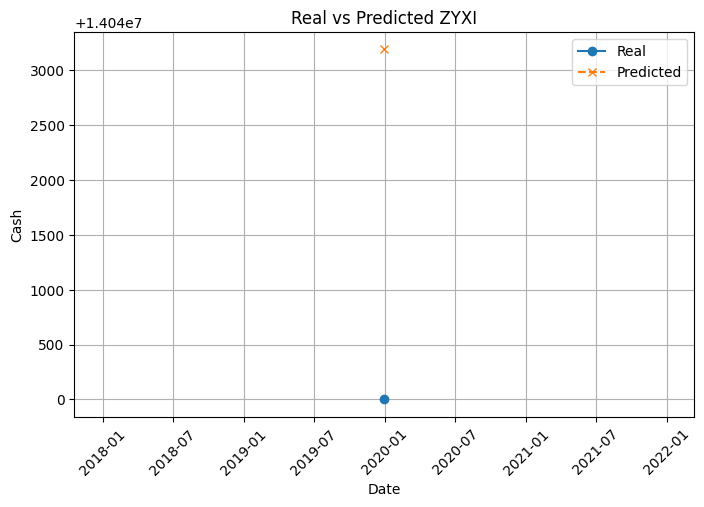

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


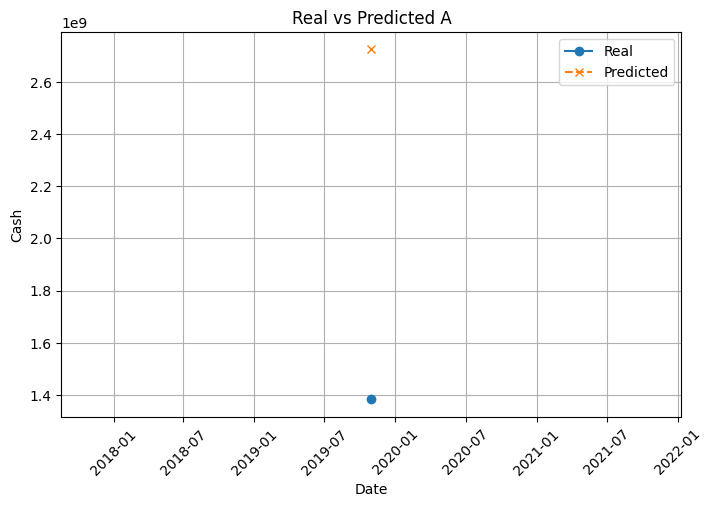

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


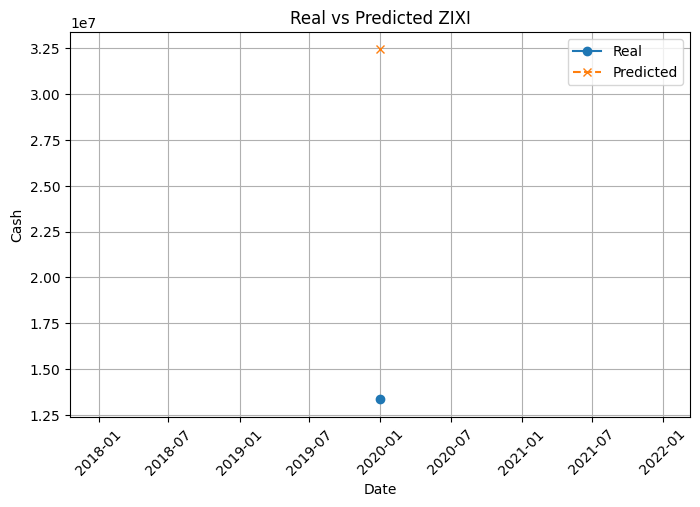

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [41]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

metrics={}

for stock in stocks:

    if stock not in predictions:
        continue

    y_test,y_pred,test=predictions[stock]

    # Verificar datos
    if len(y_test)==0:
        print("No data for",stock)
        continue

    plt.figure(figsize=(8,5))

    plt.plot(test['endDate'].values,
             y_test.values,
             marker='o',
             label="Real")

    plt.plot(test['endDate'].values,
             y_pred,
             marker='x',
             linestyle='dashed',
             label="Predicted")

    plt.title("Real vs Predicted "+stock)

    plt.xlabel("Date")

    plt.ylabel("Cash")

    plt.legend()

    plt.grid(True)

    plt.xticks(rotation=45)

    plt.show()

    mse=mean_squared_error(y_test,y_pred)

    rmse=np.sqrt(mse)

    r2=r2_score(y_test,y_pred)

    metrics[stock]=(mse,rmse,r2)

# Paso 8 — Verificación de modelos (MSE, RMSE, R2)

Instrucciones breves:
- Asegúrese de tener para cada empresa: y_test (valores reales) y y_pred (predicciones).
- Calcular métricas con sklearn: mean_squared_error(y_test, y_pred), RMSE = sqrt(MSE), r2_score(y_test, y_pred).
- Presentar los resultados en una tabla por empresa y añadir una conclusión corta.

Empresa 1 (ticker: AAA)
| Métrica | Valor |
|---|---|
| MSE |  |
| RMSE |  |
| R2 |  |

Empresa 2 (ticker: BBB)
| Métrica | Valor |
|---|---|
| MSE |  |
| RMSE |  |
| R2 |  |

Empresa 3 (ticker: CCC)
| Métrica | Valor |
|---|---|
| MSE |  |
| RMSE |  |
| R2 |  |

Pequeña conclusión:
- Comparar RMSE/MSE absolutos para evaluar error en unidades de `cash`; RMSE más bajo = mejor precisión.
- R2 indica proporción de varianza explicada (cercano a 1 → buen ajuste; cercano a 0 o negativo → mal ajuste).
- Si alguno de los modelos muestra RMSE alto o R2 bajo, considerar: más features (rezagos, variables temporales), regularización, transformación de la serie o modelos no lineales.

In [42]:
for stock in stocks:

    mse,rmse,r2=metrics[stock]

    print("Empresa:",stock)

    print("MSE:",mse)

    print("RMSE:",rmse)

    print("R2:",r2)

    print()
    print(stock)
    print(len(y_test))

Empresa: ZYXI
MSE: 10162404.047287568
RMSE: 3187.852576153353
R2: nan

ZYXI
Empresa: A
MSE: 1.8023994324383283e+18
RMSE: 1342534704.3701806
R2: nan

A
Empresa: ZIXI
MSE: 363774811111707.44
RMSE: 19072881.562881563
R2: nan

ZIXI
1


## Preguntas de Analisis

1. ¿Qué variables (features) usaste para predecir `cash` y por qué crees que son relevantes?
Se utilizó el lag1 (cash del periodo anterior) como feature porque en series temporales los valores pasados suelen ser buenos predictores de valores futuros. El cash histórico permite identificar tendencias y patrones financieros de cada empresa.

2. ¿Cómo realizaste la división temporal 80/20 por empresa y por qué es importante no barajar (shuffle) los datos en series temporales?
La división se realizó tomando:

Primer 80% → entrenamiento
Último 20% → prueba

No se deben mezclar los datos porque las series temporales tienen dependencia temporal. Si se mezclan los datos el modelo estaría aprendiendo del futuro, lo cual genera data leakage.


3. ¿Cuál es la diferencia entre MSE y RMSE y qué nos dice cada métrica sobre la precisión de las predicciones?
MSE (Mean Squared Error)
Mide el error cuadrático promedio.

RMSE (Root Mean Squared Error)
Es la raíz del MSE y está en las mismas unidades que cash.

Diferencia clave:

MSE penaliza más errores grandes
RMSE es más interpretable porque está en USD

4. ¿Qué interpreta el valor de R² en este problema (predicción de `cash`) y qué limitaciones tiene su interpretación en series temporales?
R² indica qué porcentaje de la variabilidad del cash puede ser explicada por el modelo.

Ejemplo:

R² = 0.85

Significa que el modelo explica 85% de la variabilidad.

Limitaciones:

No mide estabilidad temporal
No detecta overfitting temporal
Puede ser engañoso en series no estacionarias

5. Si obtienes un RMSE alto o un R² bajo, ¿qué acciones concretas propondrías para mejorar el modelo (p. ej. features, rezagos, transformaciones, modelos alternativos)?
Algunas mejoras posibles:

Features

Más lags (lag2, lag3)
Moving averages
Diferencias temporales
Variables financieras adicionales

Transformaciones

Log(cash)
Diferenciación temporal
Normalización

Modelos alternativos

Ridge Regression
Random Forest
XGBoost
ARIMA
LSTM

Ingeniería temporal

Año
Mes
Trimestre
